In [38]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv('QueryResults.csv',names=['DATE','TAGS','POSTS'],header=0)

Matplotlib is building the font cache; this may take a moment.


In [39]:
df.head()

,DATE,TAGS,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,8
2,2008-08-01 00:00:00,javascript,162
3,2008-08-01 00:00:00,c,85
4,2008-08-01 00:00:00,python,124


In [40]:
type(df.DATE[1])

str

In [41]:
df.DATE=pd.to_datetime(df.DATE)
df.head()

,DATE,TAGS,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,8
2,2008-08-01,javascript,162
3,2008-08-01,c,85
4,2008-08-01,python,124


In [42]:
reshaped_df=df.pivot(index='DATE',columns='TAGS',values='POSTS')

In [43]:
reshaped_df.shape

(145, 14)

In [44]:
reshaped_df.head()

TAGS,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,8.0,85.0,511.0,164.0,14.0,NaN,222.0,162.0,28.0,161.0,124.0,NaN,73.0,NaN
2008-09-01,28.0,321.0,1649.0,755.0,105.0,NaN,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,NaN
2008-10-01,15.0,303.0,1989.0,811.0,112.0,NaN,1153.0,725.0,127.0,617.0,510.0,NaN,249.0,NaN
2008-11-01,17.0,259.0,1730.0,735.0,141.0,NaN,958.0,579.0,97.0,504.0,452.0,1.0,160.0,NaN


In [45]:
reshaped_df.tail()


TAGS,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2020-03-01,317.0,2670.0,8954.0,5107.0,181.0,719.0,13253.0,20483.0,215.0,6672.0,26673.0,5761.0,780.0,3434.0
2020-04-01,406.0,3472.0,10042.0,6820.0,250.0,887.0,15377.0,24634.0,240.0,8060.0,32605.0,7047.0,860.0,4015.0
2020-05-01,386.0,3602.0,9923.0,7063.0,221.0,826.0,14711.0,25196.0,228.0,7917.0,34478.0,6833.0,774.0,4066.0
2020-06-01,363.0,2757.0,9064.0,6161.0,214.0,765.0,13015.0,23360.0,203.0,7188.0,31817.0,6249.0,670.0,3733.0
2020-07-01,298.0,2294.0,9145.0,5756.0,212.0,743.0,12723.0,23802.0,182.0,7334.0,31261.0,5694.0,775.0,3607.0


In [46]:
reshaped_df.columns

Index(['assembly', 'c', 'c#', 'c++', 'delphi', 'go', 'java', 'javascript',
       'perl', 'php', 'python', 'r', 'ruby', 'swift'],
      dtype='object', name='TAGS')

In [47]:
reshaped_df.count()
reshaped_df.fillna(0, inplace=True) 
reshaped_df.head()

TAGS,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,8.0,85.0,511.0,164.0,14.0,0.0,222.0,162.0,28.0,161.0,124.0,0.0,73.0,0.0
2008-09-01,28.0,321.0,1649.0,755.0,105.0,0.0,1137.0,640.0,131.0,482.0,542.0,6.0,290.0,0.0
2008-10-01,15.0,303.0,1989.0,811.0,112.0,0.0,1153.0,725.0,127.0,617.0,510.0,0.0,249.0,0.0
2008-11-01,17.0,259.0,1730.0,735.0,141.0,0.0,958.0,579.0,97.0,504.0,452.0,1.0,160.0,0.0


In [48]:
reshaped_df.isna().values.any()

np.False_

In [49]:
#To get sum of all values of colum
reshaped_df.sum()


TAGS
assembly        34852.0
c              336042.0
c#            1423530.0
c++            684210.0
delphi          46212.0
go              47499.0
java          1696403.0
javascript    2056510.0
perl            65286.0
php           1361988.0
python        1496210.0
r              356799.0
ruby           214582.0
swift          273055.0
dtype: float64

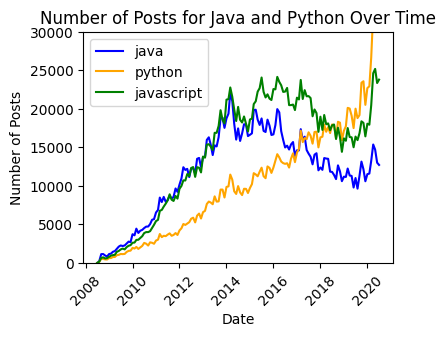

In [69]:
plt.figure(figsize=(4,3))
plt.xticks(rotation=45)
plt.ylim(0,30000)
plt.plot(reshaped_df.java, label='java', color='blue')
# plt.plot(reshaped_df.index, reshaped_df.java)
plt.plot(reshaped_df.python, label='python', color='orange')
plt.plot(reshaped_df.javascript, label='javascript', color='green')
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.title('Number of Posts for Java and Python Over Time')
plt.legend() 


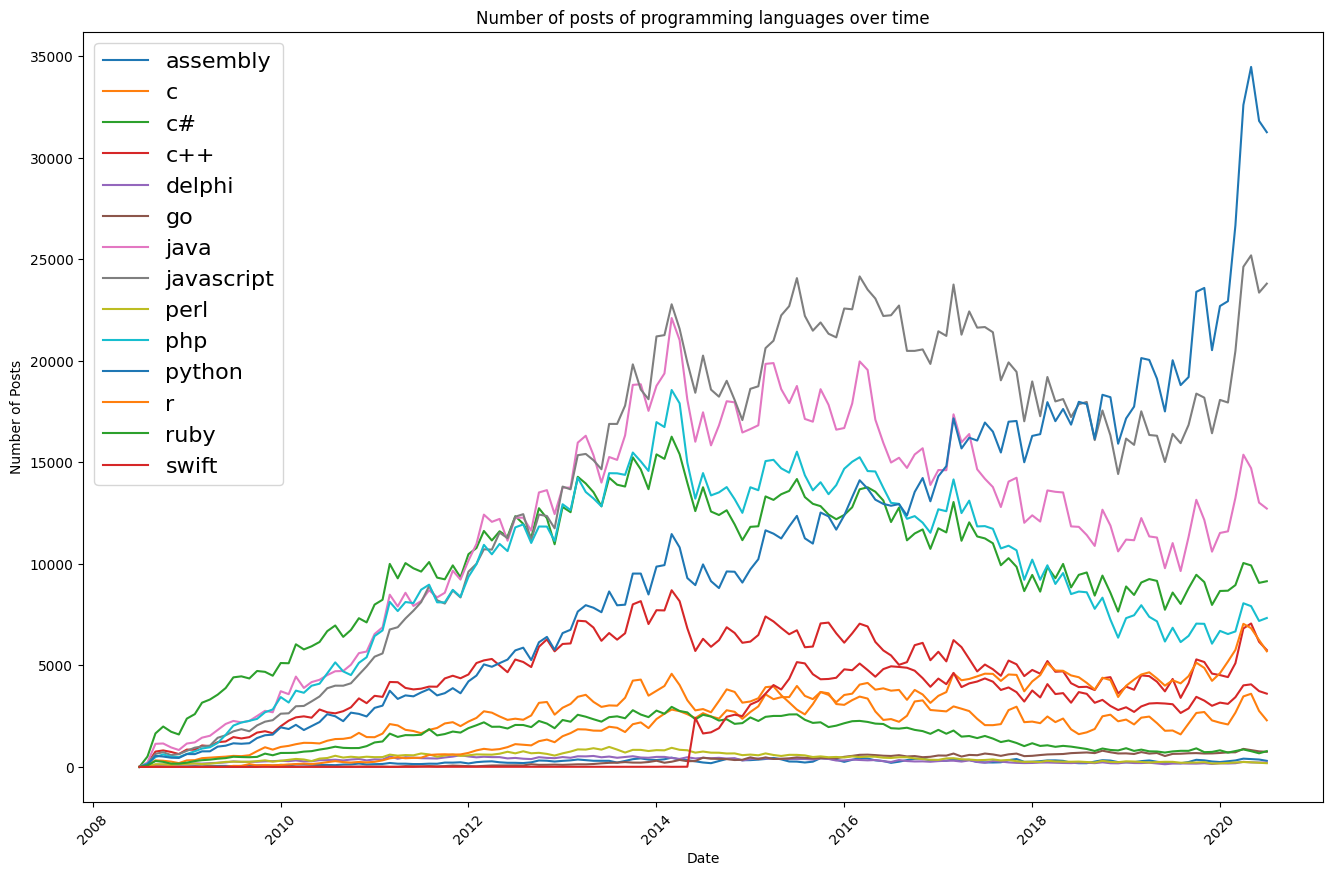

In [73]:
plt.figure(figsize=(16,10))
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.title('Number of posts of programming languages over time')
for column in reshaped_df.columns:
    plt.plot(reshaped_df.index,reshaped_df[column],label=column)
plt.legend(fontsize=16)

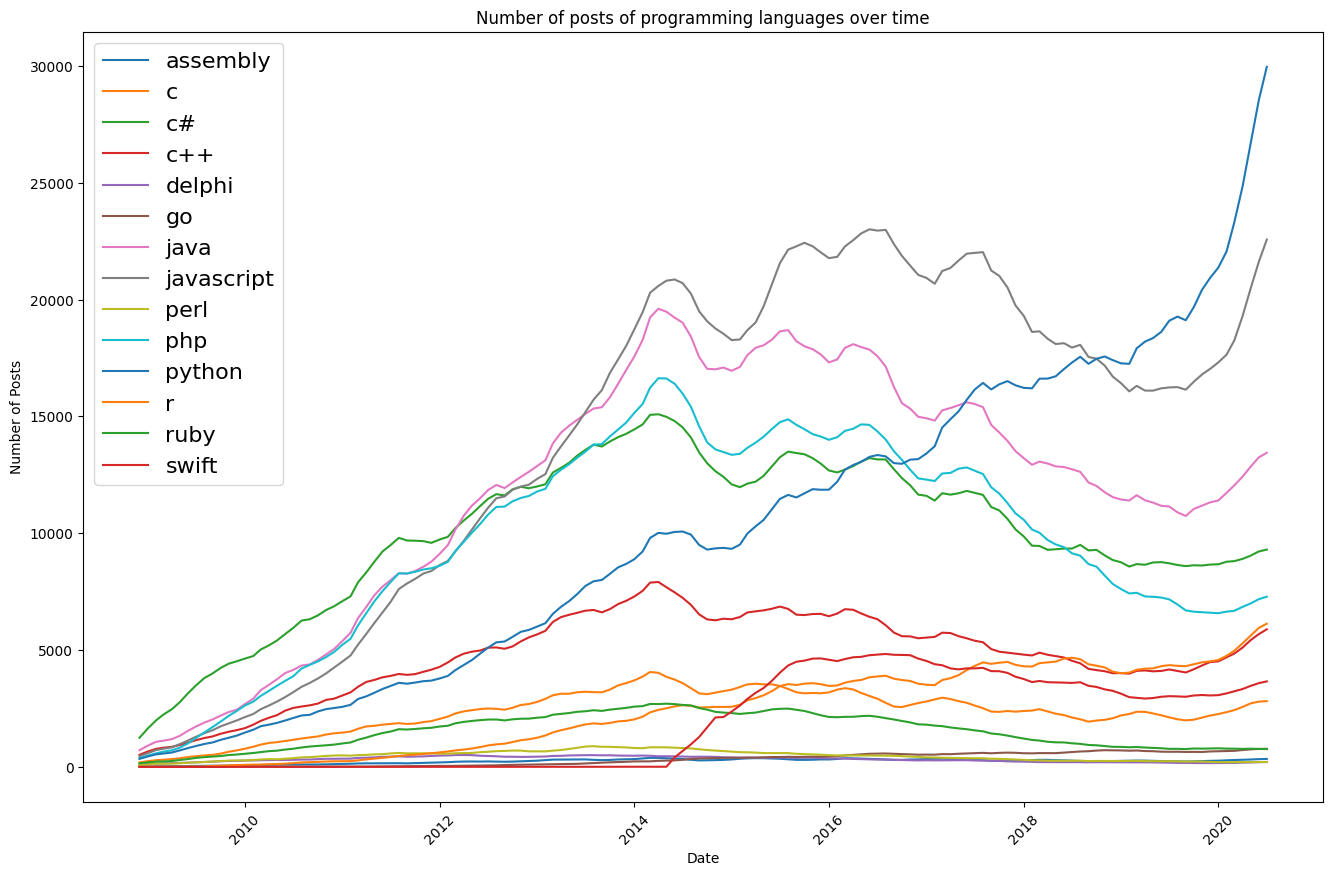

In [78]:
roll_df=reshaped_df.rolling(window=6).mean()
plt.figure(figsize=(16,10))
plt.xticks(rotation=45)
plt.xlabel('Date')
plt.ylabel('Number of Posts')
plt.title('Number of posts of programming languages over time')
for column in roll_df.columns:
    plt.plot(roll_df.index,roll_df[column],label=column)
plt.legend(fontsize=16)